## EDA PROJECT - SPOTIFY ANALYSIS

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv('spotify-tracks-dataset.csv')

EXPLORING THE DATA

In [6]:
print(df.shape)
print((df.columns))
print(df.dtypes)
print(df.head())
print(df.tail())
print(df.describe())

(114000, 22)
Index(['Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists', 'album_name',
       'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability',
       'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')
Unnamed: 0.1          int64
Unnamed: 0            int64
track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object
   Unnamed:

CHECKING THE QUALITY OF THE DATA

In [7]:
print(df.isnull().sum())
print(df.duplicated().sum())
df.info()
print(df.select_dtypes(include= 'number').columns)
print(df.select_dtypes(include= 'object').columns)

Unnamed: 0.1        0
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64
0
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  str    
 3   artists           113999 non-null  str    
 4   album_name        113999 non-null  str    
 5   track_name        113999 non-null  str    
 6   popularity  

C:\Users\user\AppData\Local\Temp\ipykernel_15436\342275066.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include= 'object').columns)


CLEANING AND PREPARING THE DATA

In [8]:
print(df[df[['artists', 'album_name', 'track_name']].isnull().any(axis=1)])
print(df['artists'].nunique())
print(df['track_name'].nunique())
print(df['track_genre'].unique())
print(df[['Unnamed: 0', 'Unnamed: 0.1']].head())
df.drop(columns = ['Unnamed: 0', 'Unnamed: 0.1'], inplace= True)
print(df.columns)
df.dropna(inplace= True)
print(df.isnull().sum())
print(df.shape)

       Unnamed: 0.1  Unnamed: 0                track_id artists album_name  \
65900         65900       65900  1kR4gIb7nGxHPI3D2ifs59     NaN        NaN   

      track_name  popularity  duration_ms  explicit  danceability  ...  \
65900        NaN           0            0     False         0.501  ...   

       loudness  mode  speechiness  acousticness  instrumentalness  liveness  \
65900     -9.46     0       0.0605          0.69           0.00396    0.0747   

       valence    tempo  time_signature  track_genre  
65900    0.734  138.391               4        k-pop  

[1 rows x 22 columns]
31437
73608
<StringArray>
[   'acoustic',    'afrobeat',    'alt-rock', 'alternative',     'ambient',
       'anime', 'black-metal',   'bluegrass',       'blues',      'brazil',
 ...
     'spanish',       'study',     'swedish',   'synth-pop',       'tango',
      'techno',      'trance',    'trip-hop',     'turkish', 'world-music']
Length: 114, dtype: str
   Unnamed: 0  Unnamed: 0.1
0           0

UNIVARIATE ANALYSIS

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='str')
228031.15338731042
212906.0
8586
5237295
(113999, 20)


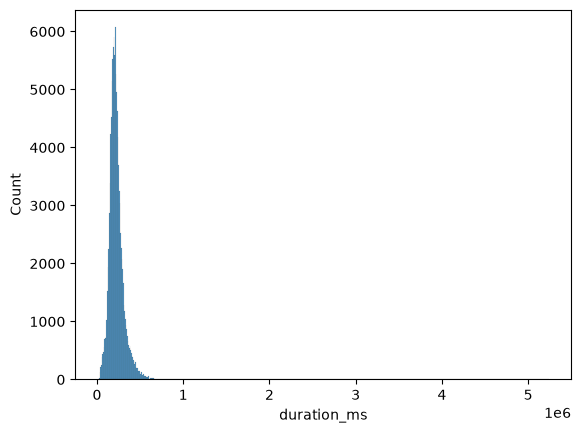

In [9]:
print(df.columns)
print(df['duration_ms'].mean())
print(df['duration_ms'].median())
print(df['duration_ms'].min())
print(df['duration_ms'].max())
print(df.shape)
sns.histplot(data= df, x='duration_ms')
plt.show()

Insight: Most Spotify tracks have relatively short durations, while a small number of unusually long tracks create a strong right-skew in the distribution.

EXPLORING RELATIONSHIP BETWEEN AUDIO FEATURES

In [11]:
print(df['energy'].mean())
print(df['energy'].median())
print(df['energy'].min())
print(df['energy'].max())

0.6413832705304432
0.685
0.0
1.0


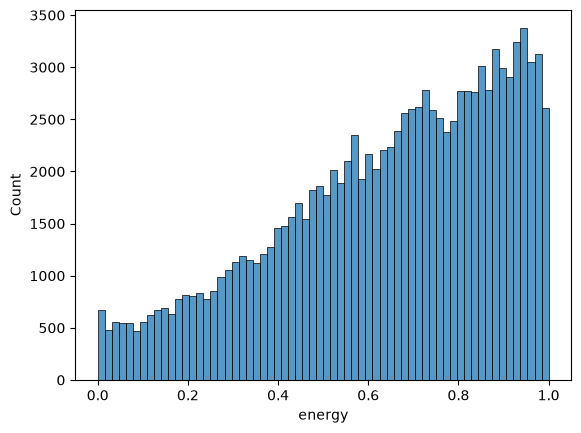

In [12]:
sns.histplot(data= df, x= 'energy')
plt.show()

Insight
Most tracks have relatively high energy levels, with many tracks concentrated between 0.7 and 1.0. This suggests that energetic tracks are more common in this dataset.

In [13]:
print(df['danceability'].mean())
print(df['danceability'].median())
print(df['danceability'].min())
print(df['danceability'].max())

0.5668006429880964
0.58
0.0
0.985


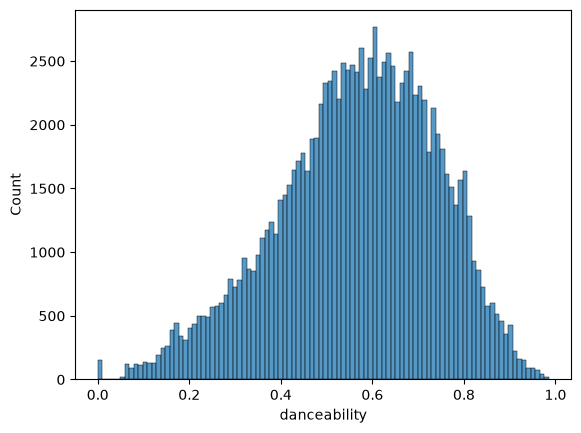

In [14]:
sns.histplot(data= df, x= 'danceability')
plt.show()

Insight: Most Spotify tracks have moderate to high danceability, with the distribution concentrated around 0.5–0.7, indicating that many tracks are reasonably danceable.

In [15]:
print(df['loudness'].mean())
print(df['loudness'].median())
print(df['loudness'].min())
print(df['loudness'].max())

-8.25894983289327
-7.004
-49.531
4.532


<Axes: xlabel='loudness', ylabel='Count'>

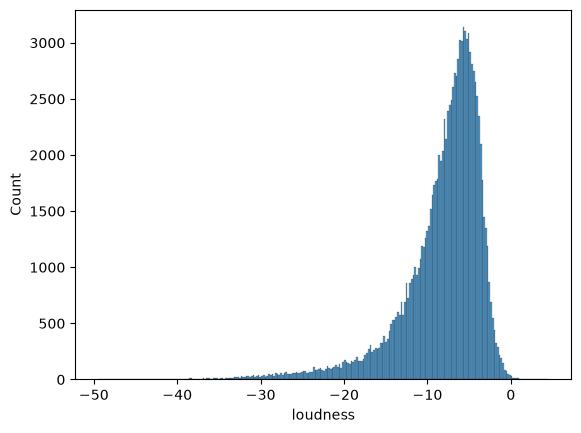

In [16]:
sns.histplot(data= df, x= 'loudness')

Insight: Most Spotify tracks have moderate loudness levels, concentrated around −10 to −5 dB, while a smaller number of tracks are much quieter.

In [17]:
print(df['speechiness'].mean())
print(df['speechiness'].median())
print(df['speechiness'].min())
print(df['speechiness'].max())

0.08465232414319424
0.0489
0.0
0.965


<Axes: xlabel='speechiness', ylabel='Count'>

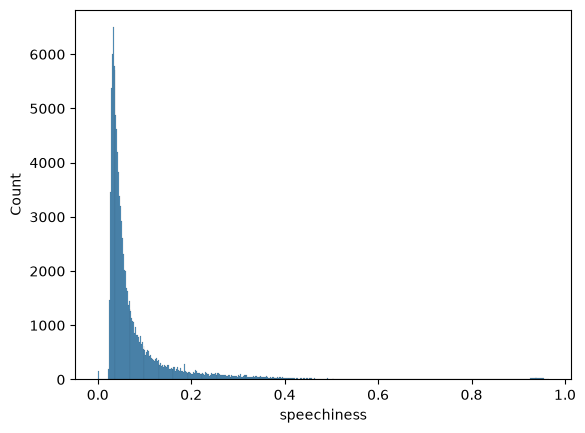

In [18]:
sns.histplot(data= df, x= 'speechiness')

Insight: Most Spotify tracks have low speechiness, indicating that the dataset is dominated by songs with little spoken-word content.

In [19]:
print(df['acousticness'].mean())
print(df['acousticness'].median())
print(df['acousticness'].min())
print(df['acousticness'].max())

0.314906772188528
0.169
0.0
0.996


<Axes: xlabel='acousticness', ylabel='Count'>

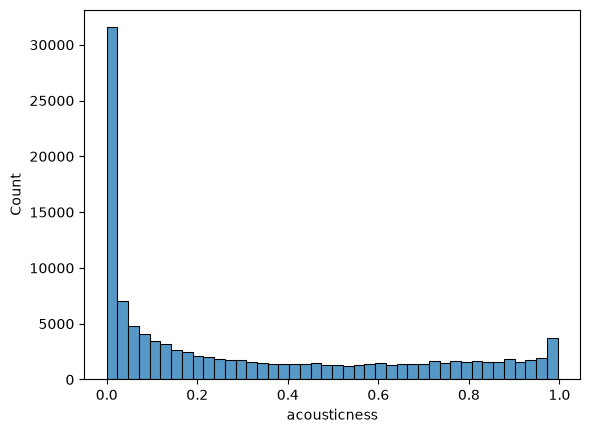

In [20]:
sns.histplot(data= df, x = 'acousticness')

Insight: Most Spotify tracks have low acousticness, suggesting that the dataset contains more electronically produced tracks than highly acoustic tracks.

In [21]:
print(df['instrumentalness'].mean())
print(df['instrumentalness'].median())
print(df['instrumentalness'].min())
print(df['instrumentalness'].max())

0.15605092335213466
4.16e-05
0.0
1.0


<Axes: xlabel='instrumentalness', ylabel='Count'>

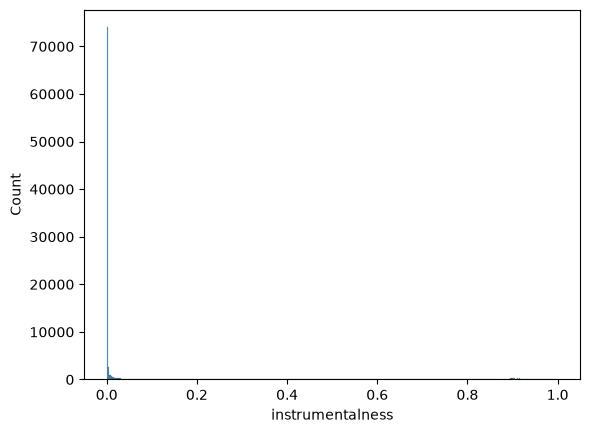

In [22]:
sns.histplot(data= df, x= 'instrumentalness')

Insight: Most Spotify tracks have very low instrumentalness, indicating that the dataset is dominated by vocal tracks rather than purely instrumental music.

In [23]:
print(df['liveness'].mean())
print(df['liveness'].median())
print(df['liveness'].min())
print(df['liveness'].max())

0.21355405407064973
0.132
0.0
1.0


<Axes: xlabel='liveness', ylabel='Count'>

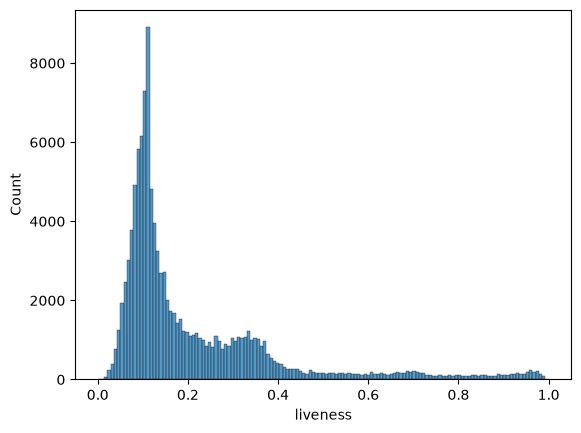

In [24]:
sns.histplot(data= df, x= 'liveness')

Insight: Most tracks have low liveness values, while only a small number of tracks have high liveness, indicating that most songs are not strongly associated with live performances.

In [25]:
print(df['valence'].mean())
print(df['valence'].median())
print(df['valence'].min())
print(df['valence'].max())

0.47406595085044606
0.464
0.0
0.995


<Axes: xlabel='valence', ylabel='Count'>

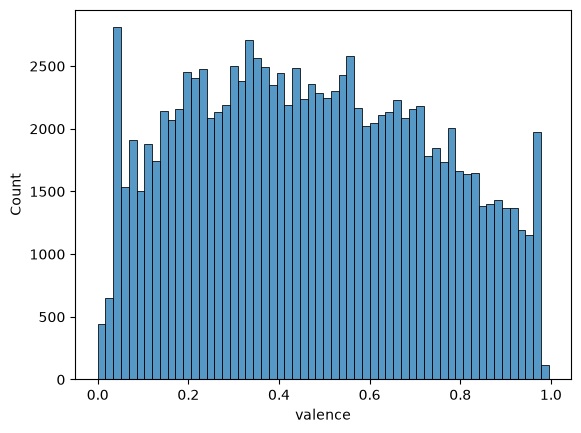

In [26]:
sns.histplot(data= df, x= 'valence')

Insight: Track valence is fairly distributed across the range, with a slight concentration around moderate values, indicating a mix of positive and less-positive sounding tracks.

In [27]:
print(df['tempo'].mean())
print(df['tempo'].median())
print(df['tempo'].min())
print(df['tempo'].max())

122.14769480434038
122.017
0.0
243.372


<Axes: xlabel='tempo', ylabel='Count'>

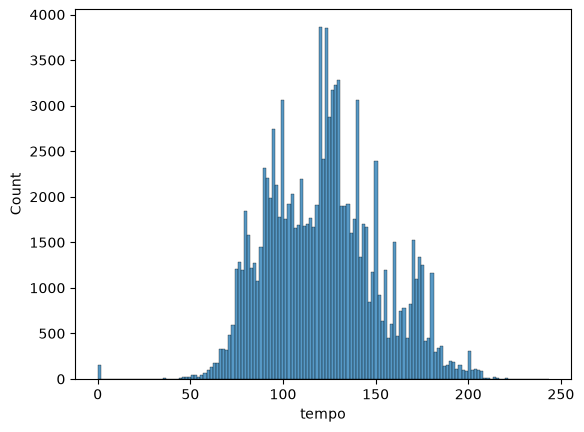

In [28]:
sns.histplot(data= df, x= 'tempo')

Insight: Most Spotify tracks have a moderate tempo, with the distribution centered around 120 BPM, while very slow and very fast tracks are relatively uncommon.

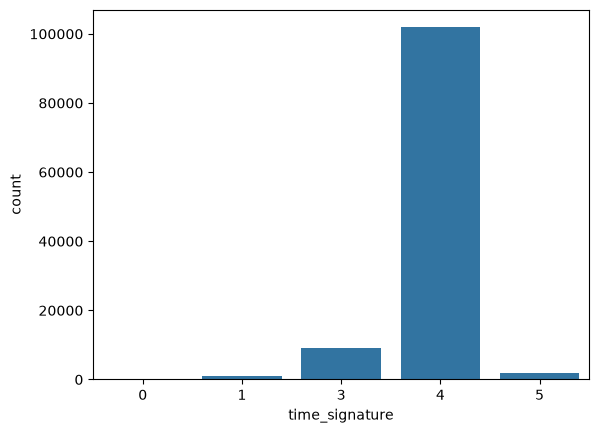

In [29]:
sns.countplot(data= df, x= 'time_signature')
plt.show()

Insight: Most Spotify tracks use a 4/4 time signature, making it by far the most common rhythmic structure in the dataset.

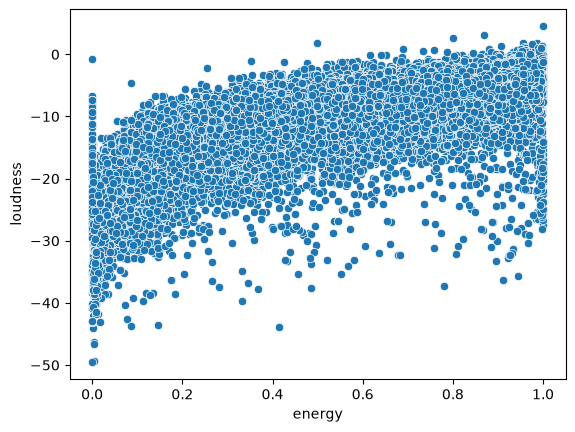

In [30]:
sns.scatterplot(data= df, x='energy', y= 'loudness')
plt.show()

Insight: Tracks with higher energy levels generally tend to be louder, showing a positive relationship between energy and loudness.

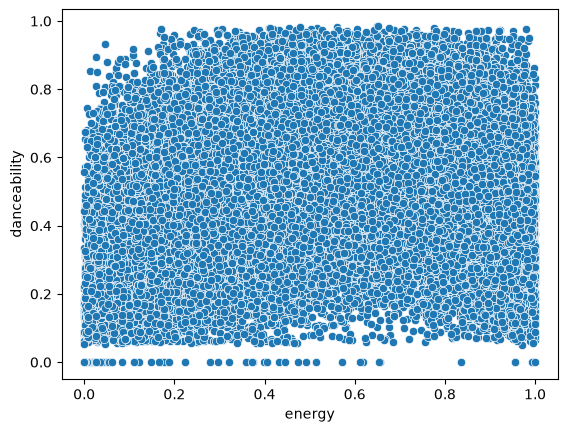

In [31]:
sns.scatterplot(data= df, x='energy', y='danceability')
plt.show()

Insight: Energy and danceability show a weak relationship, as danceability varies widely across different energy levels.

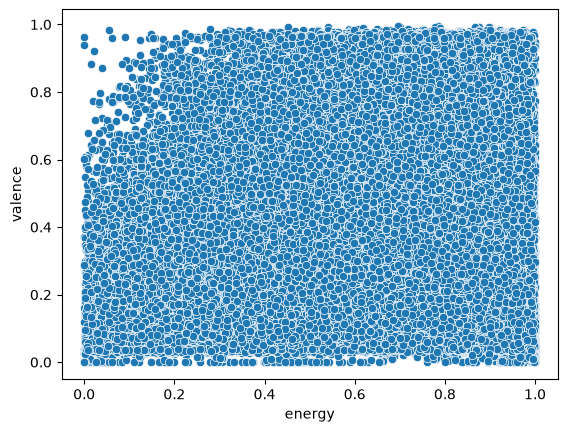

In [32]:
sns.scatterplot(data= df, x='energy', y='valence')
plt.show()

Insight: Energy and valence show a weak positive relationship, with higher-energy tracks tending to have slightly higher valence.

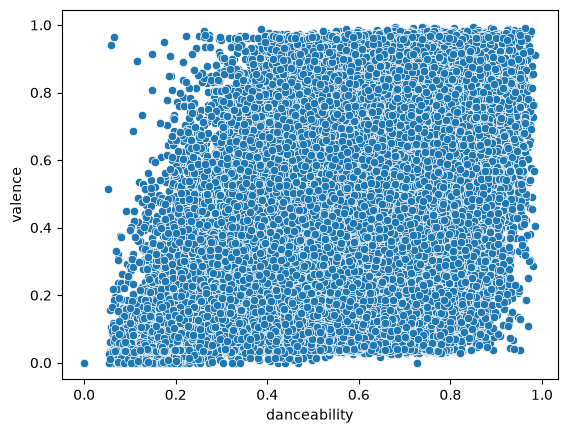

In [33]:
sns.scatterplot(data=df, x='danceability', y='valence')
plt.show()

Insight: Danceability and valence show a moderate positive relationship, indicating that more danceable tracks tend to have a more positive/happier mood.

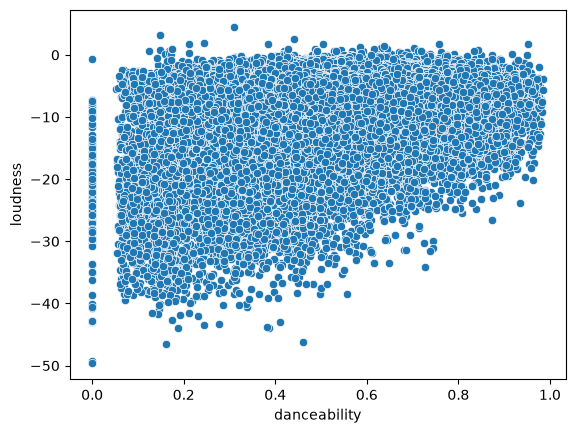

In [34]:
sns.scatterplot(data=df, x='danceability', y='loudness')
plt.show()

Insight: Danceability and loudness show a moderate positive relationship, suggesting that louder tracks tend to be somewhat more danceable.

CORRELATION ANALYSIS

In [35]:
corr= df.corr(numeric_only= True)
corr

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
popularity,1.000000,-0.007129,0.044078,0.035444,0.001053,-0.003847,0.050420,-0.013948,-0.044930,-0.025458,-0.095147,-0.005397,-0.040522,0.013212,0.031076
duration_ms,-0.007129,1.000000,-0.065270,-0.073435,0.058520,0.008123,-0.003475,-0.035581,-0.062605,-0.103770,0.124364,0.010308,-0.154464,0.024356,0.018229
explicit,0.044078,-0.065270,1.000000,0.122506,0.096954,0.004485,0.108587,-0.037216,0.307951,-0.094400,-0.103405,0.032547,-0.003378,-0.002815,0.038387
danceability,0.035444,-0.073435,0.122506,1.000000,0.134325,0.036470,0.259076,-0.069224,0.108625,-0.171531,-0.185608,-0.131620,0.477347,-0.050448,0.207219
energy,0.001053,0.058520,0.096954,0.134325,1.000000,0.048007,0.761690,-0.078365,0.142508,-0.733908,-0.181880,0.184795,0.258937,0.247852,0.187127
key,-0.003847,0.008123,0.004485,0.036470,0.048007,1.000000,0.038591,-0.135911,0.020419,-0.040942,-0.006821,-0.001597,0.034099,0.010914,0.015064
loudness,0.050420,-0.003475,0.108587,0.259076,0.761690,0.038591,1.000000,-0.041768,0.060826,-0.589804,-0.433478,0.076897,0.279851,0.212447,0.191992
mode,-0.013948,-0.035581,-0.037216,-0.069224,-0.078365,-0.135911,-0.041768,1.000000,-0.046535,0.095568,-0.049961,0.014004,0.021964,0.000572,-0.024090
speechiness,-0.044930,-0.062605,0.307951,0.108625,0.142508,0.020419,0.060826,-0.046535,1.000000,-0.002184,-0.089617,0.205218,0.036637,0.017274,-0.000011
acousticness,-0.025458,-0.103770,-0.094400,-0.171531,-0.733908,-0.040942,-0.589804,0.095568,-0.002184,1.000000,0.104033,-0.020693,-0.107081,-0.208231,-0.176142


In [36]:
print(df.drop(columns= ['Unnamed: 0', 'Unnamed: 0.1'], errors='ignore'))
print(df.shape)
print(df.columns.tolist())

                      track_id                 artists  \
0       5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1       4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2       1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3       6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4       5vjLSffimiIP26QG5WcN2K        Chord Overstreet   
...                        ...                     ...   
113995  2C3TZjDRiAzdyViavDJ217           Rainy Lullaby   
113996  1hIz5L4IB9hN3WRYPOCGPw           Rainy Lullaby   
113997  6x8ZfSoqDjuNa5SVP5QjvX           Cesária Evora   
113998  2e6sXL2bYv4bSz6VTdnfLs        Michael W. Smith   
113999  2hETkH7cOfqmz3LqZDHZf5           Cesária Evora   

                                               album_name  \
0                                                  Comedy   
1                                        Ghost (Acoustic)   
2                                          To Begin Again   
3       Crazy Rich Asians (Original Motion Picture Sou...  

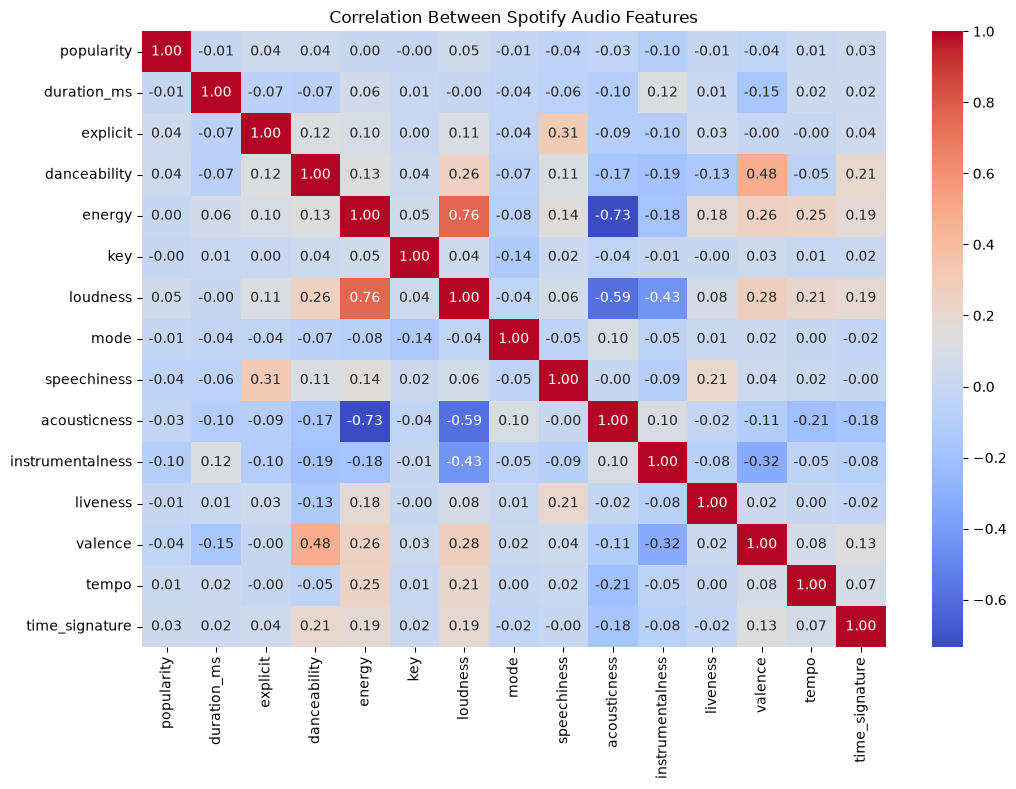

In [37]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Spotify Audio Features")
plt.show()

Insight: Popularity shows very weak linear correlations with the audio features. Loudness has the strongest positive correlation (0.05), while instrumentalness has the strongest negative correlation (-0.095). Overall, no individual audio feature appears to have a strong linear relationship with track popularity.

POPULARITY ANALYSIS

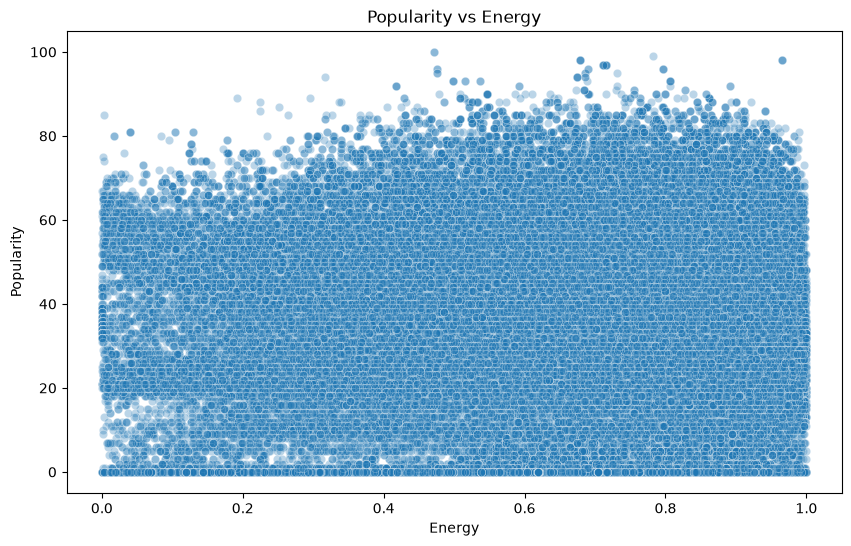

In [38]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="energy", y="popularity", alpha=0.3)

plt.title("Popularity vs Energy")
plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.show()

Insight: Popularity is concentrated below 80 across almost the entire range of energy levels. The scatterplot does not show a clear relationship between energy and popularity, which is consistent with the near-zero correlation (0.001).

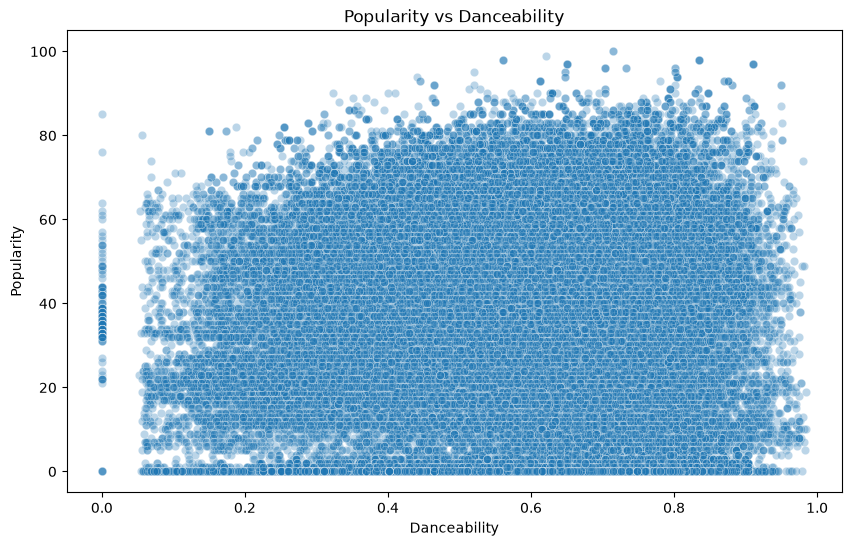

In [39]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="danceability", y="popularity", alpha=0.3)

plt.title("Popularity vs Danceability")
plt.xlabel("Danceability")
plt.ylabel("Popularity")
plt.show()

Insight: Danceability and popularity show only a very weak positive linear correlation (0.035). However, the scatterplot shows a noticeable floor effect: at low danceability, tracks can have popularity anywhere from very low to high, while higher danceability levels contain fewer extremely low-popularity tracks. Most tracks are concentrated around danceability 0.4–0.8 and popularity 40–70. Interestingly, a vertical cluster appears at danceability = 0, which may warrant further investigation.

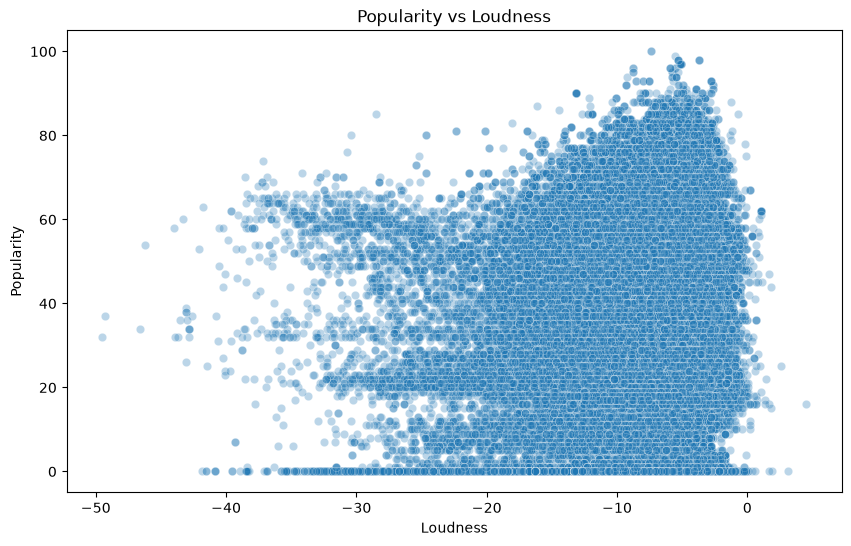

In [40]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="loudness", y="popularity", alpha=0.3)

plt.title("Popularity vs Loudness")
plt.xlabel("Loudness")
plt.ylabel("Popularity")

plt.show()

Insight: Most tracks have loudness levels between −20 and −1 dB, with popularity spread widely across this range. There is no clear relationship between loudness and popularity, suggesting that loudness alone does not strongly influence a track's popularity.

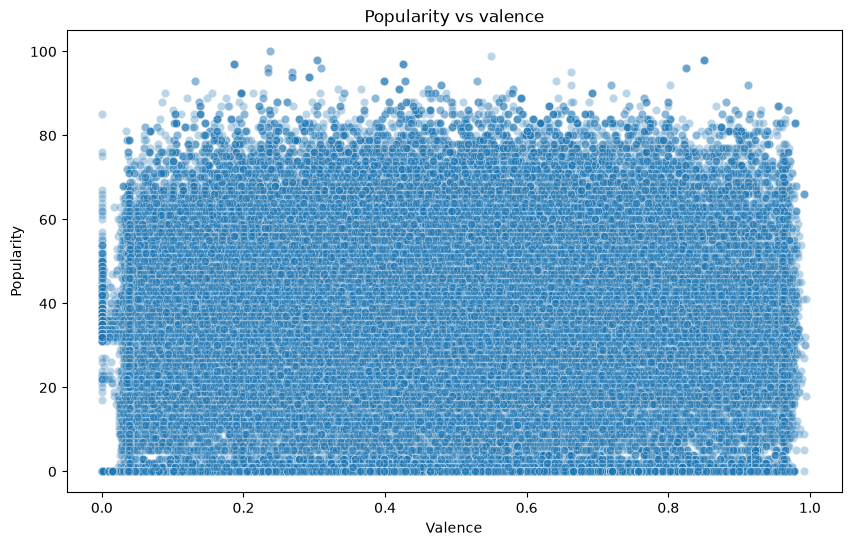

In [41]:
plt.figure(figsize = (10,6))
sns.scatterplot(data= df, x= 'valence', y= 'popularity', alpha= 0.3)

plt.title('Popularity vs valence')
plt.xlabel('Valence')
plt.ylabel('Popularity')
plt.show()

Insight: Valence and popularity show no clear relationship. Tracks across the full valence range can have popularity scores from 0 to 100, suggesting that both positive- and negative-sounding tracks can achieve high popularity. The vertical cluster at valence = 0 also appears to warrant further investigation.

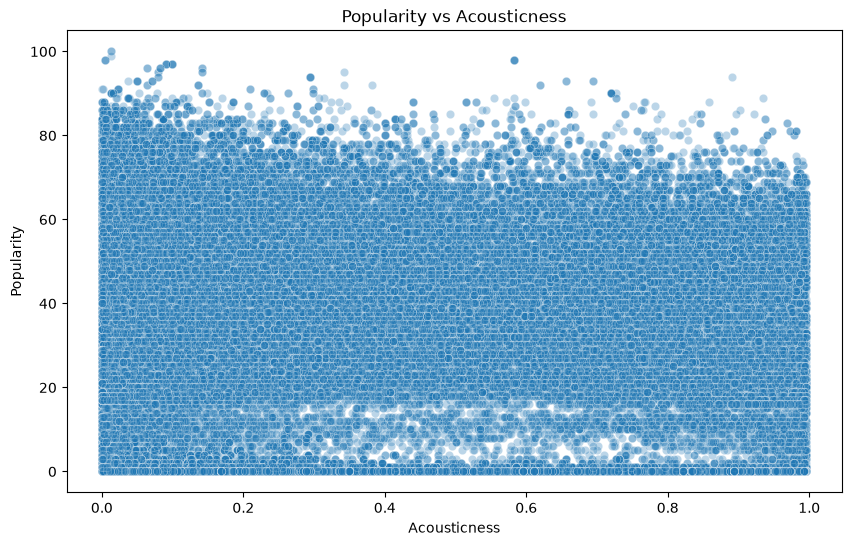

In [42]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="acousticness", y="popularity", alpha=0.3)

plt.title("Popularity vs Acousticness")
plt.xlabel("Acousticness")
plt.ylabel("Popularity")

plt.show()

Insight: Acousticness and popularity show no clear relationship. Tracks with both low and high acousticness appear across the full popularity range, although extremely acoustic tracks are slightly less common among the highest-popularity songs. Overall, the relationship is very weak.

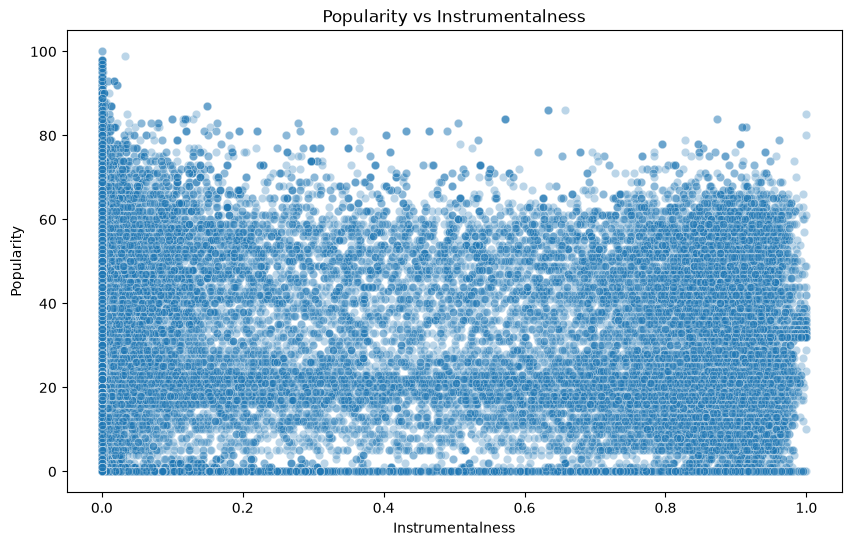

In [43]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="instrumentalness", y="popularity", alpha=0.3)

plt.title("Popularity vs Instrumentalness")
plt.xlabel("Instrumentalness")
plt.ylabel("Popularity")

plt.show()

Insight: Instrumentalness shows a weak negative relationship with popularity. Most tracks have very low instrumentalness and span a wide range of popularity, while tracks with higher instrumentalness tend to have lower popularity and are rarely among the most popular tracks. However, the relationship is not strong enough to conclude that instrumentalness alone determines popularity.

GENRE ANALYSIS

In [44]:
genre_popularity= df.groupby('track_genre')['popularity'].mean().sort_values(ascending= False)
top_genre= genre_popularity.head(10)
bottom_genre= genre_popularity.tail(10)

genre_comparison= pd.concat([top_genre, bottom_genre])
print(genre_comparison)

track_genre
pop-film          59.283000
k-pop             56.952953
chill             53.651000
sad               52.379000
grunge            49.594000
indian            49.539000
anime             48.772000
emo               48.128000
sertanejo         47.866000
pop               47.576000
idm               15.766000
kids              14.888000
grindcore         14.625000
jazz              13.628000
classical         13.055000
chicago-house     12.339000
detroit-techno    11.174000
latin              8.297000
romance            3.245000
iranian            2.210000
Name: popularity, dtype: float64


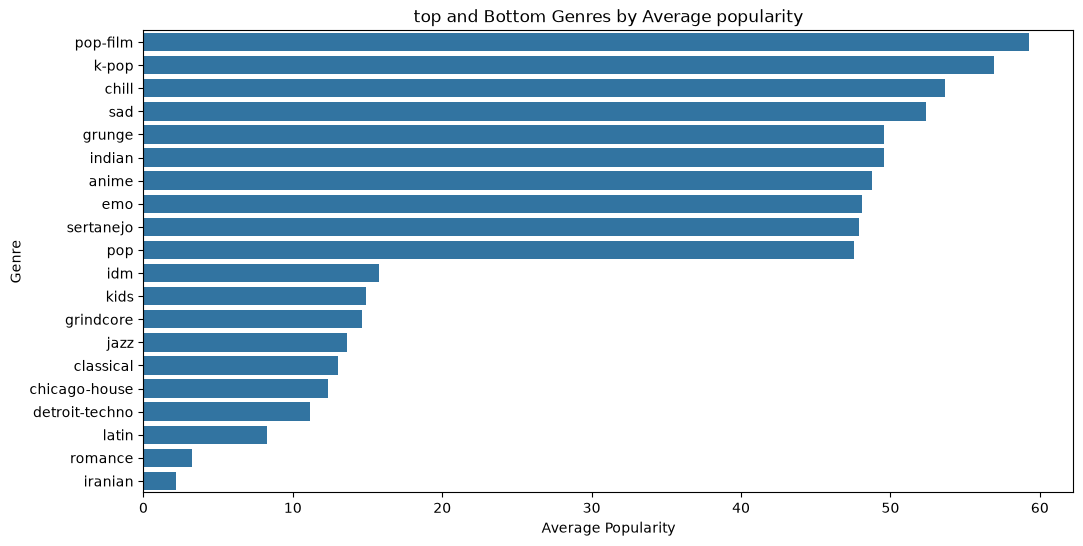

In [45]:
plt.figure(figsize = (12,6))

sns.barplot( x= genre_comparison.values, y= genre_comparison.index)

plt.title('top and Bottom Genres by Average popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Genre')
plt.show()

Insight: Average track popularity varies substantially across genres. Pop-film has the highest average popularity at around 59, while Iranian has the lowest at around 2. This highlights a strong difference in popularity across music genres.

In [46]:
genre_count = df['track_genre'].value_counts()
genre_count.head(10)

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64

Insight: Each genre contains 1,000 tracks, providing a balanced basis for comparing average popularity across genres.

In [47]:
genre_popularity = df.groupby('track_genre')['popularity'].max().sort_values(ascending= False)
print(genre_popularity)

track_genre
dance        100
pop          100
hip-hop       99
latin         98
latino        98
            ... 
study         55
grindcore     46
tango         46
romance       35
iranian       33
Name: popularity, Length: 114, dtype: int64


Insight: While average popularity differs substantially across genres, individual tracks can achieve very high popularity even within lower-average genres. This suggests that genre alone does not determine whether a track becomes popular.

In [48]:
idx = df.groupby("track_genre")["popularity"].idxmax()

most_popular_by_genre = df.loc[idx, ["track_genre", "track_name", "artists", "popularity"]]

most_popular_by_genre.sort_values("popularity", ascending=False).head(10)

,track_genre,track_name,artists,popularity
20001,dance,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
81051,pop,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
51664,hip-hop,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99
67356,latin,La Bachata,Manuel Turizo,98
68303,latino,La Bachata,Manuel Turizo,98
89411,reggaeton,La Bachata,Manuel Turizo,98
88410,reggae,La Bachata,Manuel Turizo,98
30003,edm,I'm Good (Blue),David Guetta;Bebe Rexha,98
91003,rock,I Ain't Worried,OneRepublic,96
79000,piano,I Ain't Worried,OneRepublic,96


Insight: Several highly popular tracks appear across multiple genre categories. For example, “La Bachata” is listed under four genres, each with a popularity of 98. This suggests that genre classification can overlap and that popular tracks may appeal across multiple musical categories.

ARTIST ANALYSIS

In [49]:
artists_popularity = df.groupby('artists')['popularity'].max().sort_values(ascending= False)
print(artists_popularity)

artists
Sam Smith;Kim Petras                         100
Bizarrap;Quevedo                              99
David Guetta;Bebe Rexha                       98
Manuel Turizo                                 98
Bad Bunny;Chencho Corleone                    97
                                            ... 
Chino & Nacho;Daddy Yankee;Don Omar;Wisin      0
Chino & Nacho;Baroni                           0
Chilly Gonzales;Johannes Bornlöf               0
Sohrab Motabar                                 0
Nosa                                           0
Name: popularity, Length: 31437, dtype: int64


In [50]:
artist_track_count = df['artists'].value_counts()
artist_track_count.head(10)
artist_track_count.tail(10)

artists
Chris Tomlin;Tyler Hubbard                             1
Estudio Hermoso                                        1
Christy Nockels                                        1
for KING & COUNTRY;Lecrae;The WRLDFMS Tony Williams    1
Bethel Music;John Wilds                                1
Paz Interior                                           1
Bethel Music;Molly Skaggs                              1
Cuencos Tibetanos Sonidos Relajantes                   1
Bryan & Katie Torwalt;Brock Human                      1
Jesus Culture                                          1
Name: count, dtype: int64

In [51]:
artist_stats = df.groupby("artists").agg(
    track_count=("popularity", "count"),
    avg_popularity=("popularity", "mean")
)

artist_stats = artist_stats[artist_stats["track_count"] >= 10]

artist_stats.sort_values("avg_popularity", ascending=False).head(10)

,track_count,avg_popularity
artists,,
Bad Bunny,48,87.083333
Marshmello;Khalid,10,84.000000
Måneskin,12,83.666667
Ariana Grande,11,81.454545
Clairo,10,77.000000
Farruko,13,76.692308
Radiohead,20,76.650000
Travis Scott,18,76.277778
Labrinth,12,76.083333


Insights: Among artists with at least 10 tracks in the dataset, Bad Bunny has the highest average popularity at 87.1, followed by Marshmello & Khalid and Måneskin. This shows that popularity can vary substantially across artists, even when comparing artists with a meaningful number of tracks.

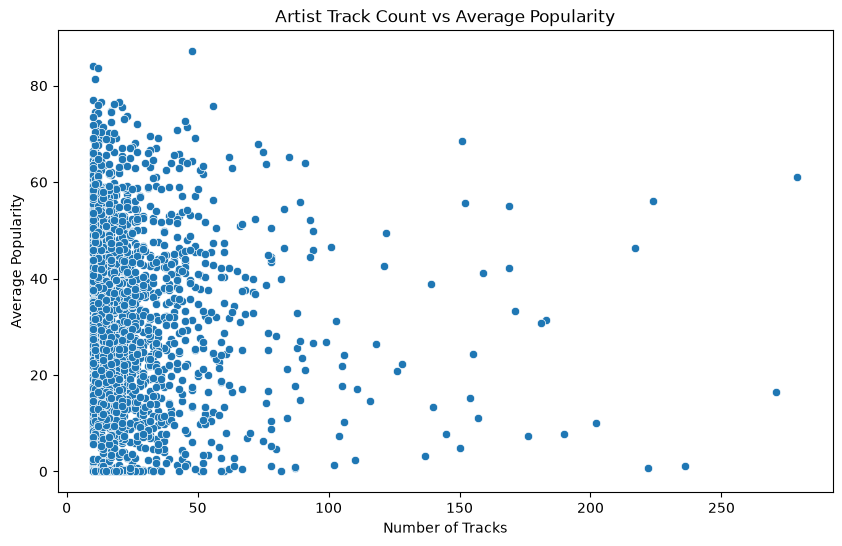

In [52]:
plt.figure(figsize= (10,6))

sns.scatterplot(data = artist_stats, x='track_count', y='avg_popularity')

plt.title('Artist Track Count vs Average Popularity')
plt.xlabel('Number of Tracks')
plt.ylabel('Average Popularity')
plt.show()

Insight: Artist track count shows no clear relationship with average popularity. Artists with fewer tracks display a much wider range of average popularity, while artists with many tracks tend to have more stable averages. This suggests that track count affects the reliability of the average more than popularity itself.

EXPLICIT VS NON-EXPLICIT POPULARITY

In [53]:
explicit_popularity = df.groupby('explicit')['popularity'].mean()
explicit_popularity

explicit
False    32.938207
True     36.454191
Name: popularity, dtype: float64

Insight: Explicit tracks have a slightly higher average popularity (36.45) than non-explicit tracks (32.94). This suggests a modest association between explicit content and higher popularity, although explicitness alone does not determine a track's popularity.

In [54]:
df['explicit'].value_counts()

explicit
False    104252
True       9747
Name: count, dtype: int64

Insight: The dataset is heavily dominated by explicit tracks, with around 91% of tracks classified as explicit. Therefore, the slightly higher average popularity of explicit tracks should be interpreted cautiously, as the two groups are highly imbalanced.

In [55]:
genre_explicit_popularity = df.groupby(['track_genre', 'explicit'])['popularity'].mean()
genre_explicit_popularity

track_genre  explicit
acoustic     False       43.148734
             True        30.346154
afrobeat     False       24.359470
             True        26.555556
alt-rock     False       33.623941
                           ...    
trip-hop     False       34.541361
             True        32.733333
turkish      False       40.964194
             True        39.743119
world-music  False       41.873000
Name: popularity, Length: 220, dtype: float64

In [56]:
genre_mean = df.groupby(['track_genre','explicit'])['popularity'].mean()
genre_mean

track_genre  explicit
acoustic     False       43.148734
             True        30.346154
afrobeat     False       24.359470
             True        26.555556
alt-rock     False       33.623941
                           ...    
trip-hop     False       34.541361
             True        32.733333
turkish      False       40.964194
             True        39.743119
world-music  False       41.873000
Name: popularity, Length: 220, dtype: float64

In [57]:
non_explicit_df= df[df['explicit'] == False]
explicit_df = df[df['explicit'] == True]

In [58]:
genre_popular_df = non_explicit_df.groupby('track_genre')['popularity'].mean()
genre_popular_df

track_genre
acoustic       43.148734
afrobeat       24.359470
alt-rock       33.623941
alternative    24.552632
ambient        44.125628
                 ...    
techno         38.935318
trance         37.531697
trip-hop       34.541361
turkish        40.964194
world-music    41.873000
Name: popularity, Length: 114, dtype: float64

In [59]:
genre_popular = explicit_df.groupby('track_genre')['popularity'].mean()
genre_popular

track_genre
acoustic       30.346154
afrobeat       26.555556
alt-rock       39.321429
alternative    23.237805
ambient        57.200000
                 ...    
synth-pop      47.045455
techno         43.038462
trance         42.227273
trip-hop       32.733333
turkish        39.743119
Name: popularity, Length: 106, dtype: float64

In [60]:
non_explicit_popular = non_explicit_df.groupby('track_genre')['popularity'].mean() 
non_explicit_popular

track_genre
acoustic       43.148734
afrobeat       24.359470
alt-rock       33.623941
alternative    24.552632
ambient        44.125628
                 ...    
techno         38.935318
trance         37.531697
trip-hop       34.541361
turkish        40.964194
world-music    41.873000
Name: popularity, Length: 114, dtype: float64

In [61]:
explicit_popular = explicit_df.groupby('track_genre')['popularity'].mean() 
explicit_popular

track_genre
acoustic       30.346154
afrobeat       26.555556
alt-rock       39.321429
alternative    23.237805
ambient        57.200000
                 ...    
synth-pop      47.045455
techno         43.038462
trance         42.227273
trip-hop       32.733333
turkish        39.743119
Name: popularity, Length: 106, dtype: float64

In [62]:
explicit_df.shape
non_explicit_df.shape

(104252, 20)

In [63]:
explicit_concate = pd.concat([explicit_popular, non_explicit_popular], axis= 1)
explicit_concate


,popularity,popularity
track_genre,,
acoustic,30.346154,43.148734
afrobeat,26.555556,24.359470
alt-rock,39.321429,33.623941
alternative,23.237805,24.552632
ambient,57.200000,44.125628
...,...,...
honky-tonk,NaN,16.355000
sleep,NaN,35.071000
study,NaN,26.108000


In [64]:
explicit_concate.columns=['explicit_popularity', 'non_explicit_popularity']
explicit_concate

,explicit_popularity,non_explicit_popularity
track_genre,,
acoustic,30.346154,43.148734
afrobeat,26.555556,24.359470
alt-rock,39.321429,33.623941
alternative,23.237805,24.552632
ambient,57.200000,44.125628
...,...,...
honky-tonk,NaN,16.355000
sleep,NaN,35.071000
study,NaN,26.108000


In [65]:
explicit_concate['popularity_difference'] = (explicit_concate['explicit_popularity'] - explicit_concate['non_explicit_popularity']).abs()
explicit_concate

,explicit_popularity,non_explicit_popularity,popularity_difference
track_genre,,,
acoustic,30.346154,43.148734,12.802580
afrobeat,26.555556,24.359470,2.196085
alt-rock,39.321429,33.623941,5.697488
alternative,23.237805,24.552632,1.314827
ambient,57.200000,44.125628,13.074372
...,...,...,...
honky-tonk,NaN,16.355000,NaN
sleep,NaN,35.071000,NaN
study,NaN,26.108000,NaN


In [66]:
explicit_concate['popularity_difference'].sort_values(ascending= False)

track_genre
k-pop          38.365349
soul           25.404791
j-idol         25.318318
country        24.679038
hip-hop        21.253647
                 ...    
honky-tonk           NaN
sleep                NaN
study                NaN
tango                NaN
world-music          NaN
Name: popularity_difference, Length: 114, dtype: float64

In [67]:
explicit_concate.columns

Index(['explicit_popularity', 'non_explicit_popularity',
       'popularity_difference'],
      dtype='str')

In [68]:
explicit_concate.sort_values(by='popularity_difference', ascending=False).head(5)

,explicit_popularity,non_explicit_popularity,popularity_difference
track_genre,,,
k-pop,20.469388,58.834737,38.365349
soul,42.557692,17.152902,25.404791
j-idol,50.000000,24.681682,25.318318
country,40.966667,16.287629,24.679038
hip-hop,23.285266,44.538913,21.253647


Insight: The relationship between explicitness and popularity varies substantially across genres. Non-explicit tracks are much more popular in genres such as K-pop and hip-hop, while explicit tracks are more popular in genres such as soul, J-idol, and country. This suggests that explicitness alone does not determine popularity; its association with popularity depends on the genre.

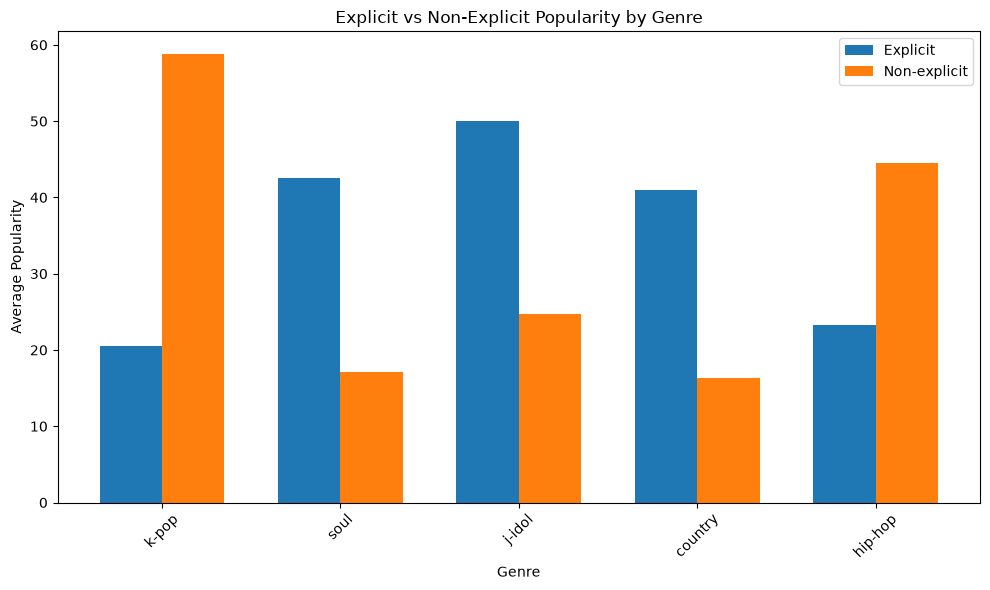

In [69]:
top5 = explicit_concate.sort_values(by='popularity_difference', ascending=False).head(5)

x = np.arange(len(top5))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, top5['explicit_popularity'], width,
        label='Explicit')

plt.bar(x + width/2, top5['non_explicit_popularity'], width,
        label='Non-explicit')

plt.xticks(x, top5.index, rotation=45)
plt.xlabel('Genre')
plt.ylabel('Average Popularity')
plt.title('Explicit vs Non-Explicit Popularity by Genre')
plt.legend()

plt.tight_layout()
plt.show()

FEATURE ENGINEERING - TRACK DURATION

In [70]:
df['duration_min'] = df['duration_ms'] /1000 / 60
df['duration_min']

0         3.844433
1         2.493500
2         3.513767
3         3.365550
4         3.314217
            ...   
113995    6.416650
113996    6.416667
113997    4.524433
113998    4.731550
113999    4.030433
Name: duration_min, Length: 113999, dtype: float64

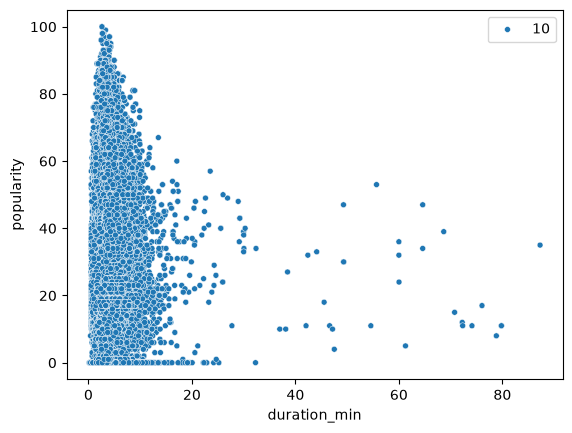

In [71]:
sns.scatterplot(data= df, x= 'duration_min', y= 'popularity', size= 10)
plt.show()

Insight: Most tracks cluster tightly between 0–15 minutes and span almost the full popularity range from 0–100. Very few tracks have durations beyond 20 minutes, and these tracks are mostly concentrated below 50 in popularity. This suggests that extremely long tracks are generally less popular in this dataset, although duration alone does not appear to strongly determine popularity.

## FINAL INSIGHTS & CONCLUSION

INSIGHT 1: AUDIO FEATURE - 
Individual audio features such as energy, danceability, loudness, valence, and tempo show very weak relationships with track popularity. This suggests that no single audio characteristic strongly determines how popular a track becomes.

INSIGHT 2: GENRE - 
Average popularity varies substantially across genres. In this dataset, pop-film has the highest average popularity at about 59.28, while Iranian has the lowest at about 2.21 — a difference of more than 57 popularity points. K-pop is also among the highest-ranked genres, with an average popularity of about 56.95.

INSIGHT 3: ARTIST - 
Among artists with at least 10 tracks in the dataset, Bad Bunny has the highest average popularity at about 87.1. However, artist track count itself shows no clear relationship with average popularity. Artists with fewer tracks have a much wider range of average popularity, while artists with more tracks tend to have more stable averages.

INSIGHT 4: EXPLICITNESS - 
The relationship between explicitness and popularity differs substantially across genres. Non-explicit tracks are much more popular in genres such as K-pop and hip-hop, while explicit tracks are more popular in genres such as soul, J-idol, and country. This suggests that explicitness alone does not determine a track's popularity; its association with popularity depends on the genre.

INSIGHT 5: DURATION & INSTRUMENTALNESS - 
Very long tracks are generally less popular in this dataset, with tracks longer than about 20 minutes mostly falling below 50 in popularity. Similarly, tracks with higher instrumentalness tend to have lower popularity and are rarely among the most popular tracks. However, neither characteristic alone appears strong enough to explain popularity.


## OVERALL CONCLUSION

This analysis shows that Spotify track popularity cannot be explained by a single audio feature. Most audio features have very weak relationships with popularity, while genre and artist show much larger differences in average popularity. The relationship between explicitness and popularity also changes across genres. Overall, popularity appears to be influenced by multiple factors rather than one simple characteristic, making it a complex and context-dependent outcome.